In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (2,)),
    tf.keras.layers.Dense(20,activation = 'tanh'),
    tf.keras.layers.Dense(20,activation = 'tanh'),
    tf.keras.layers.Dense(20,activation = 'tanh'),
    tf.keras.layers.Dense(1),
])

In [3]:
def pde(model,x,t,nu = 0.01):
  with tf.GradientTape(persistent = True) as tape:
    tape.watch(x)
    tape.watch(t)

    inputs = tf.concat([x,t], axis=1)
    u = model(inputs)

    u_x = tape.gradient(u,x)
    u_t = tape.gradient(u,t)

  u_xx = tape.gradient(u_x,x)

  del tape

  return u_t + u*u_x - (nu/np.pi)*u_xx

In [4]:
def initial_condition(x):
  return -tf.sin(np.pi*x)

In [5]:
def boundary_condition(t):
  return tf.zeros_like(t)

In [6]:
x = tf.convert_to_tensor(
    np.linspace(-1, 1, 200)[:, None],
    dtype=tf.float32
)

t = tf.convert_to_tensor(
    np.linspace(0, 1, 100)[:, None],
    dtype=tf.float32
)

In [7]:
X, T = tf.meshgrid(
    tf.squeeze(x),
    tf.squeeze(t),
    indexing='ij'
)

x_train = tf.reshape(X, (-1,1))
t_train = tf.reshape(T, (-1,1))

In [8]:
def loss_fn(model,x,t):

  res = pde(model,x,t)
  loss_pde = tf.reduce_mean(tf.square(res))

  t_0 = tf.zeros_like(t)
  points_x = tf.concat([x,t_0], axis=1)
  u_nn_0 = model(points_x)
  u_0 = initial_condition(x)

  loss_u_0 = tf.reduce_mean(tf.square(u_nn_0 - u_0))

  x_b1 = tf.ones_like(t) * 1
  points_t = tf.concat([x_b1,t], axis=1)
  u_nn_b1 = model(points_t)
  u_b = boundary_condition(t)

  loss_u_b1 = tf.reduce_mean(tf.square(u_nn_b1 - u_b))

  x_b2 = tf.ones_like(t) * -1
  points_t = tf.concat([x_b2,t], axis=1)
  u_nn_b2 = model(points_t)
  u_b = boundary_condition(t)

  loss_u_b2 = tf.reduce_mean(tf.square(u_nn_b2 - u_b))

  return loss_pde + loss_u_0 + loss_u_b1 + loss_u_b2

In [9]:
def train(model,x,t,epochs,optimizer):
  for epoch in range(epochs):
    with tf.GradientTape() as tape:
      loss = loss_fn(model,x,t)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    if epoch % 500 == 0:
      print("Epoch: {} Loss: {}".format(epoch, loss))

In [10]:
optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001)
train(model,x_train,t_train,10000,optimizer)

Epoch: 0 Loss: 0.6547971963882446
Epoch: 500 Loss: 0.14441907405853271
Epoch: 1000 Loss: 0.10024414956569672
Epoch: 1500 Loss: 0.08896935731172562
Epoch: 2000 Loss: 0.08250384777784348
Epoch: 2500 Loss: 0.07769452035427094
Epoch: 3000 Loss: 0.06730452924966812
Epoch: 3500 Loss: 0.040648818016052246
Epoch: 4000 Loss: 0.016032442450523376
Epoch: 4500 Loss: 0.010762457735836506
Epoch: 5000 Loss: 0.008148050867021084
Epoch: 5500 Loss: 0.006517334375530481
Epoch: 6000 Loss: 0.0053106569685041904
Epoch: 6500 Loss: 0.00455145537853241
Epoch: 7000 Loss: 0.004015880636870861
Epoch: 7500 Loss: 0.006710472516715527
Epoch: 8000 Loss: 0.003248804248869419
Epoch: 8500 Loss: 0.0029843260999768972
Epoch: 9000 Loss: 0.002762666204944253
Epoch: 9500 Loss: 0.0025852532126009464


In [11]:
inputs = tf.concat([x_train,t_train], axis=1)
u = model(inputs)

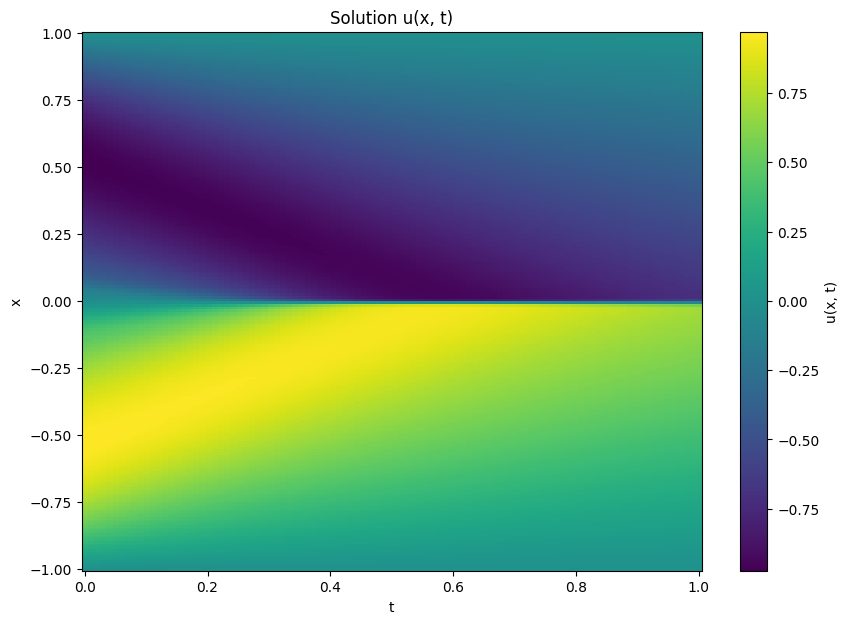

In [12]:
# Reshape u to match the original (x, t) grid dimensions
u_reshaped = tf.reshape(u, (x.shape[0], t.shape[0]))

# Create a plot
plt.figure(figsize=(10, 7))
plt.pcolormesh(T, X, u_reshaped, cmap='viridis')
plt.colorbar(label='u(x, t)')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Solution u(x, t)')
plt.show()